# 1A: Code & Answers

In [1]:
# main imports
import pandas as pd
import numpy as np

In [2]:
# import CSV and dictionary
import gdown
csv_id = '1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH'
dict_id = '1GKbh50b-NexKtv-47-y4VP1kklBIvX5p'

gdown.download(id=csv_id,output='co_occur.csv')
gdown.download(id=dict_id,output='dictionary.txt')

Downloading...
From (original): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH
From (redirected): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH&confirm=t&uuid=a9bbac06-eb94-4843-a896-d4db68844f98
To: C:\Users\ayaan\OneDrive\Desktop\VS Code Parent\svd-project\co_occur.csv
100%|██████████| 281M/281M [00:12<00:00, 22.8MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1GKbh50b-NexKtv-47-y4VP1kklBIvX5p
To: C:\Users\ayaan\OneDrive\Desktop\VS Code Parent\svd-project\dictionary.txt
100%|██████████| 79.3k/79.3k [00:00<00:00, 6.48MB/s]


'dictionary.txt'

In [3]:
# import matrix and dictionary
M = pd.read_csv('co_occur.csv',header=None).values

with open('dictionary.txt','r') as d:
    dictionary = d.read().splitlines()

print("Matrix shape:", M.shape)
print("First 10 words in dictionary:", dictionary[:10])

Matrix shape: (10000, 10000)
First 10 words in dictionary: ['the', 'of', 'in', 'and', 'to', 'was', 'is', 'for', 'on', 'as']


# 1B: Code & Answers

In [4]:
# import
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds

# normalize the matrix
M = np.log(1 + M)

# get SVDs in descending order
U, S, V_T = svds(M, k=100) #ascending order so we need to reverse
U = U[:, ::-1] #reverse columns
S = S[::-1] #reverse array
V_T = V_T[::-1, :] #reverse rows

# save the SVD
np.savez('rank-100-svd',U=U,S=S,V_T=V_T)

Matplotlib is building the font cache; this may take a moment.


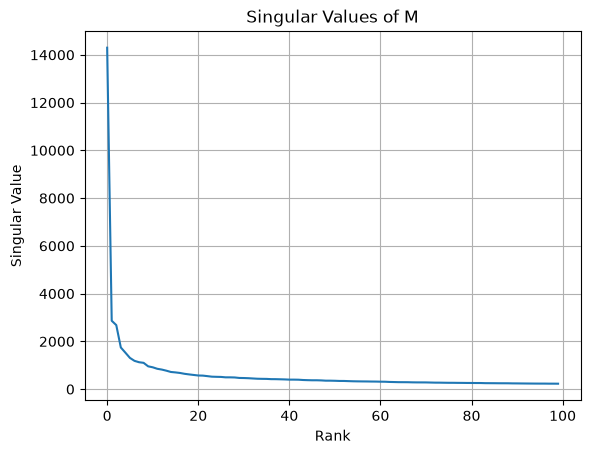

In [5]:
# plot the singular values
plt.plot(S)
plt.title('Singular Values of M')
plt.xlabel('Rank')
plt.ylabel('Singular Value')
plt.grid(True)
plt.show()

**Answer to 1B:**

M seems to be a low-rank matrix, as the singular values drop of significantly after the first few ranks. We can see this from the graph, where the singular values rapidly decrease, reaching under 2000 before rank 5.

# 1C: Code & Answers

In [9]:
for i in range(1, 10):
    print(U[:, i])
    print(np.argsort(U[:, i]))

[-0.12016923 -0.10824373 -0.10424286 ...  0.00643085  0.00563141
  0.00604263]
[   0    3    1 ... 4142 4535 3198]
[ 0.01128451  0.00974136  0.00528992 ... -0.00631828 -0.001923
 -0.0033509 ]
[ 122  128  368 ...  606  191 1173]
[ 0.00065021 -0.00479142 -0.00773151 ...  0.00164975 -0.00331231
  0.00314476]
[183 131 320 ... 327 115 196]
[-2.48661335e-03 -7.66717415e-03 -1.68114193e-03 ...  1.55477372e-03
 -9.66614910e-05  6.37124405e-04]
[344 422 935 ... 200 564 811]
[ 0.01931642  0.0044076   0.014785   ... -0.00349697 -0.00664886
 -0.00303842]
[1037  406 1153 ...  619   80 1166]
[0.01350145 0.02090915 0.01434493 ... 0.00807906 0.00457236 0.0099487 ]
[ 221 1476  882 ...  162 2415 1032]
[-0.02310324  0.01566854 -0.00921975 ...  0.00238742  0.00591517
  0.0028477 ]
[ 80 116  17 ... 846 763 268]
[ 0.01328663  0.01926088  0.00671011 ... -0.00364371  0.00061957
 -0.00166378]
[ 360  126  226 ... 1299  363  856]
[-0.01392622 -0.01945499 -0.00967637 ... -0.00566095  0.00035952
 -0.0087821 ]
[ 25